# FT-PINN (v7) — Fourier time-sequential PINN для DWO в сверхкритическом канале

**Метод:** Chen, Yang, Zhang, Liu, Yang, Lai — *A novel Fourier time-sequential PINN approach for multi-frequency analysis of nonlinear aerothermoelastic problems*, Adv. Eng. Informatics 72 (2026) 104446 (`1-s2.0-S1474034626001382-main.pdf`). Их задача — самовозбуждающийся флаттер/LCO на длинном горизонте: vanilla-PINN сходится к нулевому (гладкому) решению — в точности наша quasi-steady картина. FT-PINN держит относительную L2 ≈ 5.55·10⁻³ на всём горизонте (на 2–3 порядка лучше vanilla/MscaleDNN/ST-MFF-PINN).

**База:** ячейки 1–14 ниже — дословная копия ячеек 0–13 `pinn_v4_causal_good_enough.ipynb` (Forcing → EOS → Case → модели → Physics → Sampler → LossWeights/Trainer). Меняется ТОЛЬКО то, что вносит статья:

1. **Марш временных сегментов** (Alg. A1): одна сеть обучается последовательно по окнам; время нормируется τ̂ = (t − Γₙ₋₁)/ΔΓ ∈ [0,1] внутри окна (Eq. 13); IC окна n — мягкий шов со снимком конца окна n−1 (Eq. 18, λ_i1 = 10⁴ по Appendix B). Наша система 1-го порядка по t — Коши-данные шва = значения (G, h); у них 2-й порядок, поэтому пара (W, ∂W/∂τ).
2. **Random Fourier features** (Eq. 20–22): a(z) = [cos 2πk z; sin 2πk z], b(τ̂) = [cos 2πf τ̂; sin 2πf τ̂]; k ~ N(0, σ_ξ²), f ~ N(0, σ_τ²) фиксируются один раз; m = 128, σ_ξ = 1, σ_τ = 2 (Appendix B). Один транк Ψ (sine 2×256) на обе ветки, поля — покомпонентное произведение (separable).
3. **Жёсткие BC** (Eq. 15, наш аналог sin(πξ)): анзац выхода выполняет h*(0,t) = −N_SPC, imposed-Δp и калибровку π*(1,t) = 0 тождественно; bc_loss остаётся только монитором.
4. **Adam → L-BFGS(+ROA)** посегментно (статья: Adam 1500 итераций, затем L-BFGS с реактивацией; главные рычаги при провале — σ_τ и число шагов L-BFGS, Appendix B).

Интегральные keeper-связи движка (mom/energy/mass) сохранены на t-сетке сегмента — аналог их Φ-приёма (перевод нелокального члена в локальные связи, Eq. 8–11).

**Расписание сегментов:** ΔΓ = 20 t* до T_SWITCH = 700 t*, дальше ΔΓ = 1.6 t* ≈ 0.6 периода DWO (их выбор ΔΓ = 0.15 ≈ 0.6 периода LCO, Appendix B) → ~127 сегментов до T* = 846.
**Валидация:** независимый FV-солвер (`fv_reference_curve.npz`, `pinn_v4_fv_solver.ipynb`); графики — канонический стиль FV-ноутбука.

**Ворота (объявлены до запуска):**
- посегментно: pde < 3·10⁻³, шов < 3·10⁻⁴, keepers < 10⁻³;
- envelope: средняя ошибка огибающей G_in ≤ 3% против FV на покрытом окне;
- full: колебания при t > 1600 с; период 5.93 с ± 15%; onset 1626 с ± 15%.

**Пресеты:** `smoke` (2 сегмента, ~5–10 мин) / `envelope` (35 сегментов до 1487 с) / `full` (все ~127); `selftest` — крошечный бюджет только для проверки машинерии. Ресумабельно посегментно (`v7_ftpinn_ckpt.pt`, `RESUME=True`).

*Оговорка о директивах: запрет warm-start относится к causal-линии (v4); v7 — отдельная линия «сделай как в статье», марш с переносом состояния — сам метод статьи.*


In [1]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [2]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [3]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [4]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [5]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [6]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [7]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [8]:
class SmoothPINN(nn.Module):
    def __init__(self, t_end_star, width=128, depth=6, activation="tanh"):
        super().__init__()

        self.t_end_star = float(t_end_star)

        if activation == "tanh":
            act = nn.Tanh
        elif activation == "silu":
            act = nn.SiLU
        else:
            raise ValueError("activation must be 'tanh' or 'silu'")

        layers = []
        in_dim = 2

        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else width, width))
            layers.append(act())

        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0

        x = torch.cat([z_scaled, t_scaled], dim=1)
        y = self.head(self.net(x))

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [9]:
class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega0=1.0, first=False):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.omega0 = omega0
        self.first = first
        self.reset_parameters()

    def reset_parameters(self):
        in_dim = self.linear.in_features
        with torch.no_grad():
            if self.first:
                bound = 1.0 / in_dim
            else:
                bound = math.sqrt(6.0 / in_dim) / self.omega0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


class SirenPINN(nn.Module):
    def __init__(self, width=64, depth=4, omega0_first=30.0, omega0_hidden=1.0):
        super().__init__()
        layers = [SineLayer(2, width, omega0=omega0_first, first=True)]
        for _ in range(depth - 1):
            layers.append(SineLayer(width, width, omega0=omega0_hidden))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 4)

    def forward(self, z_star, t_star):
        x = torch.cat([z_star, t_star], dim=1)
        y = self.head(self.net(x))

        rho = F.softplus(y[:, 0:1]) + 1e-8
        G = y[:, 1:2]
        h = y[:, 2:3]
        pi = y[:, 3:4]

        return rho, G, h, pi

In [10]:
class FourierFeatures(nn.Module):
    def __init__(self, freqs=(1.0, 2.0, 4.0, 8.0)):
        super().__init__()
        self.register_buffer(
            "freqs",
            torch.tensor(freqs, dtype=torch.float32).reshape(1, 1, -1),
        )

    def forward(self, x):
        # x: [N, 2], already scaled to [-1, 1]
        xb = x.unsqueeze(-1)                         # [N, 2, 1]
        arg = math.pi * xb * self.freqs              # [N, 2, F]

        sin = torch.sin(arg).flatten(start_dim=1)
        cos = torch.cos(arg).flatten(start_dim=1)

        return torch.cat([x, sin, cos], dim=1)


class HybridPINN(nn.Module):
    def __init__(
        self,
        t_end_star,
        width_smooth=128,
        width_fourier=64,
        depth_smooth=6,
        depth_fourier=3,
        freqs=(1.0, 2.0, 4.0, 8.0),
    ):
        super().__init__()

        self.t_end_star = float(t_end_star)
        self.fourier = FourierFeatures(freqs=freqs)

        smooth_layers = []
        in_dim = 2

        for i in range(depth_smooth):
            smooth_layers.append(nn.Linear(in_dim if i == 0 else width_smooth, width_smooth))
            smooth_layers.append(nn.Tanh())

        self.smooth_net = nn.Sequential(*smooth_layers)
        self.smooth_head = nn.Linear(width_smooth, 3)

        fourier_dim = 2 + 2 * 2 * len(freqs)

        fourier_layers = []
        for i in range(depth_fourier):
            fourier_layers.append(nn.Linear(fourier_dim if i == 0 else width_fourier, width_fourier))
            fourier_layers.append(nn.Tanh())

        self.fourier_net = nn.Sequential(*fourier_layers)
        self.fourier_head = nn.Linear(width_fourier, 3)

        self.gate_logit = nn.Parameter(torch.full((1, 3), -2.0))

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def scale_inputs(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0
        return torch.cat([z_scaled, t_scaled], dim=1)

    def forward(self, z, t):
        x = self.scale_inputs(z, t)

        y_smooth = self.smooth_head(self.smooth_net(x))

        x_fourier = self.fourier(x)
        y_fourier = self.fourier_head(self.fourier_net(x_fourier))

        gate = torch.sigmoid(self.gate_logit)

        y = y_smooth + gate * y_fourier

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [11]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [12]:
class Sampler:
    def __init__(self, case, device, dtype=torch.float32, alpha=0.02):
        self.case = case
        self.device = device
        self.dtype = dtype
        self.alpha = alpha

        self.t_bc = torch.linspace(
            0.0,
            case.t_end_star,
            4096,
            device=device,
            dtype=dtype,
        ).reshape(-1, 1)

        z_in = torch.linspace(0.0, 3.0 * alpha, 512, device=device, dtype=dtype).reshape(-1, 1)
        z_mid = torch.linspace(3.0 * alpha, 1.0 - 3.0 * alpha, 1024, device=device, dtype=dtype).reshape(-1, 1)
        z_out = torch.linspace(1.0 - 3.0 * alpha, 1.0, 512, device=device, dtype=dtype).reshape(-1, 1)

        self.z_ic = torch.cat([z_in, z_mid, z_out], dim=0)

    def uniform(self, n, a, b):
        return a + (b - a) * torch.rand(
            n,
            1,
            device=self.device,
            dtype=self.dtype,
        )

    def time(self, n):
        n0 = int(0.10 * n)
        nk = int(0.20 * n)
        nf = n - n0 - nk

        t_full = self.uniform(nf, 0.0, self.case.t_end_star)

        t_start = self.uniform(
            n0,
            0.0,
            min(0.05 * self.case.t_end_star, self.case.t_end_star),
        )

        dt = min(0.5 * self.case.w0 / self.case.L, 0.05 * self.case.t_end_star)
        a = max(0.0, self.case.t_kink_star - dt)
        b = min(self.case.t_end_star, self.case.t_kink_star + dt)

        t_kink = self.uniform(nk, a, b)

        return torch.cat([t_full, t_start, t_kink], dim=0)

    def interior(self, n_in=2048, n_mid=4096, n_out=2048):
        a = self.alpha

        z_in = self.uniform(n_in, 0.0, 3.0 * a)
        z_mid = self.uniform(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = self.uniform(n_out, 1.0 - 3.0 * a, 1.0)

        return {
            "in": (z_in.requires_grad_(True), self.time(n_in).requires_grad_(True)),
            "mid": (z_mid.requires_grad_(True), self.time(n_mid).requires_grad_(True)),
            "out": (z_out.requires_grad_(True), self.time(n_out).requires_grad_(True)),
        }

    def bc(self):
        t = self.t_bc

        return {
            "in": (torch.zeros_like(t), t),
            "out": (torch.ones_like(t), t),
        }

    def ic(self):
        z = self.z_ic
        t = torch.zeros_like(z)

        return z, t


    # ---- causal training grid (Wang, Sankaran, Perdikaris 2024) ----------
    def causal_time_grid(self, n_t, t_lo=0.0, t_hi=None, jitter=True):
        # Sorted time grid t_1 < ... < t_Nt over (t_lo, t_hi]. linspace cells with
        # intra-cell jitter keep strict ordering (needed for the causal cumulative
        # sum). The left edge t_lo is the IC anchor (handled in causal_pde_loss).
        te = self.case.t_end_star if t_hi is None else t_hi
        edges = torch.linspace(t_lo, te, n_t + 1, device=self.device, dtype=self.dtype)
        left = edges[:-1]
        width = float(edges[1] - edges[0])
        if jitter:
            u = torch.rand(n_t, device=self.device, dtype=self.dtype)
        else:
            u = torch.full((n_t,), 0.5, device=self.device, dtype=self.dtype)
        t = left + u * width
        return t.reshape(-1, 1)

    def causal_space(self, n_t, n_z):
        # For each of n_t times, n_z spatial points spanning [0,1] with the
        # in/mid/out zone density of interior(). Returns (n_t, n_z): row i holds
        # the z's for time i, so a row-major flatten groups points by time.
        a = self.alpha
        n_in = max(1, round(0.25 * n_z))
        n_out = max(1, round(0.25 * n_z))
        n_mid = n_z - n_in - n_out

        def block(n, lo, hi):
            return lo + (hi - lo) * torch.rand(
                n_t, n, device=self.device, dtype=self.dtype,
            )

        z_in = block(n_in, 0.0, 3.0 * a)
        z_mid = block(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = block(n_out, 1.0 - 3.0 * a, 1.0)
        return torch.cat([z_in, z_mid, z_out], dim=1)


In [13]:
@dataclass(frozen=True)
class LossWeights:
    # per-equation weights INSIDE the per-time residual L_r(t_i)
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0

    # causal anchors (Wang+2024): IC is the t_0 segment, BC folded per-time so it
    # is gated by the same causal front as the PDE residual.
    causal_ic: float = 1000.0  # lambda_ic, matches CausalPINNs (loss =
                               # mean(W*L_t) + lambda_ic*L_ic, IC full weight).
                               # L_ic also enters every w_i's exponent, so driving
                               # IC -> ~1e-5 is what OPENS the causal gate.
    causal_bc: float = 30.0

    # causal time / space resolution
    Nt: int = 64              # number of sorted time segments
    Nz_pde: int = 96          # spatial points per time for the PDE residual
    Nz_keeper: int = 193      # spatial points per time for the integral keepers

    # integral keepers -- now causally weighted by the SAME w_i (no tail
    # concentration). They ride on the front but do not define it.
    mom_integral: float = 20.0
    energy_integral: float = 20.0
    mass_integral: float = 20.0

    # legacy fields kept so pde_loss / the diagnostic+ablation cells still
    # construct. Not used by the causal path.
    ic: float = 20.0
    bc: float = 20.0
    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    # =====================================================================
    # Causal training (Wang, Sankaran, Perdikaris, CMAME 2024; arXiv:2203.07404)
    # =====================================================================
    def ic_loss_target(self, z, t_at, G_target, h_target):
        # IC anchor against a frozen target state (G_target, h_target)(z) at time
        # t_at -- time-marching: window k>=1 pins its left edge to the previous
        # window's end-state. Same normalization as the physical ic_loss.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        R_G = (G - G_target) / self.case.G0_star
        R_h = (h - h_target) / self.case.nspc
        return {"ic_G": mse(R_G), "ic_h": mse(R_h)}

    @torch.no_grad()
    def snapshot_state(self, z, t_at):
        # Detached (G, h) profiles at time t_at from THIS model -- becomes the IC
        # target for the next marching window.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        return G.detach(), h.detach()

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        # Per-time residual L_r(t_i) = PDE (mass/mom/energy) + folded BC, computed
        # in ONE vectorized autograd pass over a (Nt, Nz) collocation grid, plus
        # the IC anchor L_0 = lambda_ic * L_ic (the t_0 segment, Eq. 3.4).
        # Returns (Lr, L0, parts): Lr is (Nt,), L0 scalar, parts for logging.
        Nt = t_grid.shape[0]

        # --- PDE residual on (Nt, Nz) points (random z per time) -------------
        z_mat = sampler.causal_space(Nt, weights.Nz_pde)     # (Nt, Nz_a)
        Nz = z_mat.shape[1]
        Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(Z, T, "mid")
        R_mass = R_mass.reshape(Nt, Nz)
        R_mom = R_mom.reshape(Nt, Nz)
        R_energy = R_energy.reshape(Nt, Nz)

        Lr_mass = (R_mass ** 2).mean(dim=1)                  # (Nt,)
        Lr_mom = (R_mom ** 2).mean(dim=1)
        Lr_energy = (R_energy ** 2).mean(dim=1)
        Lr_pde = (
            weights.mass * Lr_mass
            + weights.mom * Lr_mom
            + weights.energy * Lr_energy
        )

        # --- BC per-time (imposed Delta-p), one point per face per time ------
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)   # (Nt,)

        # BC is NOT folded into the causal residual: imposed-Delta-p is a
        # STANDING constraint (must hold at every t). Causally gating it lets the
        # high-eps weights switch off the tail BC (w_i -> 0) -> pi_out drifts and
        # Delta-p overshoots. Returned separately, enforced uniformly below.

        # --- IC anchor (left edge of the window) -----------------------------
        # window 0: physical IC at t=0; window k>=1: seam snapshot at t_lo.
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(
                ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"],
            )
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {
            "pde": Lr_pde.mean().detach(),
            "bc": Lr_bc.mean().detach(),
            "ic": L_ic.detach(),
        }
        return Lr_pde, L0, Lr_bc, parts

    def _keeper_vectors(self, t_grid, n_z=193):
        # SIGNED per-time integral residuals of the three keeper identities on a
        # uniform z-grid -- returns (mom_vec, energy_vec, mass_vec), each (Nt,),
        # with the autograd graph intact. Vectorized: one forward+autograd pass
        # over (Nt, Nz). Single source of truth for both the causal keeper loss
        # and keeper_time_profiles. Mirrors the old integral_*_loss term by term.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        Nt = t_grid.shape[0]
        z_lin = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
        dz = float(z_lin[1] - z_lin[0])

        Z = z_lin.reshape(1, n_z).expand(Nt, n_z).reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(n_z, dim=0).clone().requires_grad_(True)

        G, h, pi, _, _, _ = self.fields(Z, T)
        rho, chi_h = self.eos25(h)

        G_t = d(G, T)
        h_t = d(h, T)
        h_z = d(h, Z)
        G_z = d(G, Z)
        rho_t = chi_h * h_t

        Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
            G=G, h=h, rho=rho,
        )
        loss_flux_num = G * smooth_abs(G, eps=1e-6)
        di = delta_inlet(Z, self.alpha)
        do = delta_outlet(Z, self.alpha)

        def M(x):
            return x.reshape(Nt, n_z)

        flux = M(G ** 2 / rho)
        rho_m = M(rho)
        lfn_m = M(loss_flux_num)
        di_m = M(di)
        do_m = M(do)

        accel = torch.trapezoid(M(G_t), dx=dz, dim=1)            # (Nt,)
        gravity = torch.trapezoid(M(rho / self.case.Fr), dx=dz, dim=1)
        friction = torch.trapezoid(M(Lambda_dyn * signed_loss_flux), dx=dz, dim=1)
        flux_jump = flux[:, -1] - flux[:, 0]
        local_in = torch.trapezoid(
            0.5 * self.case.kin * di_m * lfn_m / rho_m[:, 0:1], dx=dz, dim=1,
        )
        local_out = torch.trapezoid(
            0.5 * self.case.kout * do_m * lfn_m / rho_m[:, -1:], dx=dz, dim=1,
        )
        rhs = accel + flux_jump + gravity + friction + local_in + local_out
        mom_vec = (rhs - self.case.dpi_star) / self.case.dpi_star   # (Nt,)

        R_mass_m = M(rho_t + G_z)
        R_energy_m = M(rho * h_t + G * h_z - self.NQ_prime(T)) + M(h) * R_mass_m
        energy_vec = torch.trapezoid(R_energy_m / self.case.energy_scale, dx=dz, dim=1)
        mass_vec = torch.trapezoid(R_mass_m / self.case.mass_scale, dx=dz, dim=1)

        return mom_vec, energy_vec, mass_vec

    def causal_pde_loss(self, sampler, weights, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        # Total causal loss (Eq. 3.2-3.4) over the window (t_lo, t_hi]. Builds the
        # sorted time grid, per-time residual L_r(t_i), causal weights w_i
        # (stop-gradient), the weighted sum, and the causally weighted keepers.
        t_grid = sampler.causal_time_grid(weights.Nt, t_lo, t_hi)
        Lr, L0, Lr_bc, parts = self._per_time_residual(sampler, weights, t_grid, ic_spec)

        # causal weights from PDE residual + IC anchor ONLY (BC is enforced
        # uniformly below; it must not be gated). seg[0]=IC, seg[1:]=L_r(t_i).
        seg = torch.cat([L0.reshape(1), Lr])                 # (Nt+1,)
        S = torch.cumsum(seg, dim=0) - seg                   # exclusive prefix sum
        w = torch.exp(-eps * S.detach())                     # stop-gradient on w_i
        W = w[1:]                                            # temporal weights (== CausalPINNs W)
        w_min = W.min()
        # CausalPINNs total (KS/regular_KS.py): loss = mean(W*L_t) + L_0.
        # IC anchor at FULL weight (not averaged); residual = mean of weighted chunks.
        L_weighted = L0 + (W * Lr).mean()

        # BC: uniform FULL weight at all times (NOT causally gated)
        L_bc = weights.causal_bc * Lr_bc.mean()

        # causalized keepers: same w_i, same t_grid, no tail concentration
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, weights.Nz_keeper)
        w_k = W                                              # same temporal weights as the residual
        L_mom_int = (w_k * mom_vec ** 2).mean()
        L_energy_int = (w_k * energy_vec ** 2).mean()
        L_mass_int = (w_k * mass_vec ** 2).mean()

        total = (
            L_weighted
            + L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": parts["pde"],
            "bc": parts["bc"],
            "ic": parts["ic"],
            "w_min": w_min.detach(),
            "eps": float(eps),
            # raw (unweighted) mean-square keeper drift -- comparable to old logs
            "mom_int": (mom_vec ** 2).mean().detach(),
            "energy_int": (energy_vec ** 2).mean().detach(),
            "mass_int": (mass_vec ** 2).mean().detach(),
        }
        return total, logs

    def keeper_time_profiles(self, n_t=80, n_z=193):
        # SIGNED per-time keeper integrals on a uniform time grid -- for the
        # per-keeper diagnostic and ablation. Thin detached wrapper over
        # _keeper_vectors (single source of truth with the causal loss).
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        t_grid = torch.linspace(0.0, te, n_t, device=device, dtype=dtype).reshape(-1, 1)
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, n_z)
        t_star = [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        t_sec = [x * self.case.L / self.case.w0 for x in t_star]
        return {
            "t_star": t_star,
            "t_sec": t_sec,
            "mom": [float(x) for x in mom_vec.detach().cpu()],
            "energy": [float(x) for x in energy_vec.detach().cpu()],
            "mass": [float(x) for x in mass_vec.detach().cpu()],
        }

    def causal_weight_profile(self, sampler, weights, eps, n_t=None):
        # Diagnostic: per-segment causal weight w_i and residual L_r(t_i) on a
        # no-jitter grid, for plotting the causal front. Read-only (detached).
        Nt = int(n_t or weights.Nt)
        t_grid = sampler.causal_time_grid(Nt, jitter=False)
        Lr, L0, _, _ = self._per_time_residual(sampler, weights, t_grid)
        seg = torch.cat([L0.reshape(1), Lr])
        S = torch.cumsum(seg, dim=0) - seg
        w = torch.exp(-eps * S)
        t_star = [0.0] + [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        return {
            "t_star": t_star,
            "t_sec": [x * self.case.L / self.case.w0 for x in t_star],
            "Lr": [float(L0.detach())] + [float(x) for x in Lr.detach().cpu()],
            "w": [float(x) for x in w.detach().cpu()],
        }


In [14]:
class Trainer:
    def __init__(self, model, physics, sampler, weights, lr=1e-4):
        self.model = model
        self.physics = physics
        self.sampler = sampler
        self.weights = weights
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def step(self, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        self.optimizer.zero_grad(set_to_none=True)

        loss, logs = self.physics.causal_pde_loss(
            self.sampler, self.weights, eps, t_lo, t_hi, ic_spec,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

        self.optimizer.step()

        return {
            key: (float(value.detach().cpu()) if torch.is_tensor(value) else float(value))
            for key, value in logs.items()
        }


class StitchedModel(nn.Module):
    # Routes (z, t) to the window model that owns t, so the marched solution acts
    # as one model over [0, t_end] for all the diagnostic cells. Each submodel is
    # evaluated on all points and masked (differentiable; cheap at diagnostic
    # sizes). Windows partition time as [lo, hi) except the last, which is [lo, hi].
    def __init__(self, windows, t_end_star):
        super().__init__()
        self.submodels = nn.ModuleList([m for (_, _, m) in windows])
        self.bounds = [(float(lo), float(hi)) for (lo, hi, _) in windows]
        self.t_end_star = float(t_end_star)

    def forward(self, z, t):
        G = torch.zeros_like(z)
        H = torch.zeros_like(z)
        P = torch.zeros_like(z)
        n = len(self.bounds)
        for j, ((lo, hi), m) in enumerate(zip(self.bounds, self.submodels)):
            mask = (t >= lo) & (t < hi) if j < n - 1 else (t >= lo) & (t <= hi)
            sel = mask.to(z.dtype)
            g, h, pp = m(z, t)
            G = G + sel * g
            H = H + sel * h
            P = P + sel * pp
        return G, H, P



## Сеть статьи: RFF + separable-произведение + жёсткие BC

`FTSegNet` реализует Fig. 2 / Eq. 20–22 статьи в нашем интерфейсе `model(z, t) → (G_hat, h_hat, Pi_hat)`:
- обе координаты проходят random-Fourier-отображение; частоты k, f разыгрываются один раз (Alg. A1, шаг 4) и лежат в буферах;
- один общий транк Ψ (sine-активация, `SineLayer` из базовой ячейки; RFF играет роль первого sine-слоя) применяется к a(z) и b(τ̂) по отдельности, по 3 выхода на ветку; поле = произведение веток (separable);
- жёсткие ограничения на hat-уровне (Eq. 15): `Pi_hat = (1−z) + z(1−z)·q_π` → π*(0,t) = Δπ*, π*(1,t) = 0 тождественно; `h_hat = −1 + z·q_h` → h*(0,t) = −N_SPC тождественно; `G_hat = q_G` — расход свободен (он и должен осциллировать);
- границы текущего сегмента — буферы `t_lo/t_hi`, переключаются `set_segment()`; τ̂ вычисляется из глобального t.


In [15]:
class FTSegNet(nn.Module):
    """Сеть FT-PINN (Chen+ 2026, Eq. 20-22 + Eq. 15) под интерфейс model(z,t)->(G_hat,h_hat,Pi_hat)."""

    def __init__(self, m=128, sigma_xi=1.0, sigma_tau=2.0, width=256, depth=2, seed=0):
        super().__init__()
        gen = torch.Generator().manual_seed(seed)
        # Alg. A1 шаг 4: k ~ N(0, sigma_xi^2), f ~ N(0, sigma_tau^2), фиксируются один раз
        self.register_buffer("k_vec", torch.randn(m, generator=gen) * sigma_xi)
        self.register_buffer("f_vec", torch.randn(m, generator=gen) * sigma_tau)
        # границы текущего сегмента (глобальное безразмерное время)
        self.register_buffer("t_lo", torch.tensor(0.0))
        self.register_buffer("t_hi", torch.tensor(1.0))

        layers = []
        in_dim = 2 * m
        for i in range(depth):
            # RFF выполняет роль первого sine-слоя, поэтому оба слоя транка — «скрытая» инициализация SIREN
            layers.append(SineLayer(in_dim if i == 0 else width, width, omega0=1.0, first=False))
        self.trunk = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

    def set_segment(self, t_lo, t_hi):
        self.t_lo.fill_(float(t_lo))
        self.t_hi.fill_(float(t_hi))

    def _rff(self, x, vec):
        arg = 2.0 * math.pi * x * vec.reshape(1, -1)          # (N, m)
        return torch.cat([torch.cos(arg), torch.sin(arg)], dim=1)

    def forward(self, z, t):
        tau_hat = (t - self.t_lo) / (self.t_hi - self.t_lo)   # Eq. 13: время окна в [0,1]
        qz = self.head(self.trunk(self._rff(z, self.k_vec)))          # (N,3)
        qt = self.head(self.trunk(self._rff(tau_hat, self.f_vec)))    # (N,3)
        q = qz * qt                                                   # Eq. 22: separable-произведение

        G_hat = q[:, 0:1]
        h_hat = -1.0 + z * q[:, 1:2]                          # h*(0,t) = -NSPC тождественно
        Pi_hat = (1.0 - z) + z * (1.0 - z) * q[:, 2:3]        # imposed-dp и gauge тождественно
        return G_hat, h_hat, Pi_hat


## Сегментный лосс и марш

Лосс сегмента — Eq. 16–19 статьи из штатных блоков движка: PDE-невязки `residuals_scaled` (MSE, штатные веса mass/mom/energy), мягкий IC/шов `ic_loss` / `ic_loss_target` с λ_i1 = 10⁴, интегральные keeper-связи `_keeper_vectors` на t-сетке сегмента (штатные веса). BC-члена нет — граничные условия жёсткие (монитор печатается в конце сегмента).

Обучение сегмента: Adam (свежая коллокация каждый шаг) → L-BFGS strong-Wolfe на фиксированной коллокации с ROA-lite (раунды с ресемплом точек и рестартом состояния оптимизатора; nan/ухудшение → откат к лучшим весам). Переход к сегменту n+1: `snapshot_state` конца сегмента n (детачнутые профили G, h на плотной z-сетке) становится целью шва.


In [16]:
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.manual_seed(0)

model = FTSegNet(m=128, sigma_xi=1.0, sigma_tau=2.0, width=256, depth=2, seed=0).to(device=device, dtype=dtype)

sampler = Sampler(case=case, device=device, dtype=dtype, alpha=0.02)

physics = Physics(
    model=model,
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)

# штатные веса движка (та же комбинация уравнений и keeper-веса, что в causal-запуске good_enough)
weights = LossWeights(
    mass=2.0,
    mom=0.25,
    energy=0.5,
    mom_integral=20.0,
    energy_integral=20.0,
    mass_integral=20.0,
)

SEAM_WEIGHT = 1.0e4        # lambda_i1 статьи (Appendix B); сегмент 1 — физический IC с тем же весом

# --- расписание сегментов: грубо до порога неустойчивости, дальше 0.6 периода DWO ---
DGAMMA_COARSE = 20.0       # t*
T_SWITCH = 700.0           # t*  (~1487 s — до onset 1626 s)
DGAMMA_FINE = 1.6          # t*  ~ 0.6 x период DWO (5.93 s = 2.79 t*), как dGamma=0.15 ~ 0.6 периода LCO в статье


def build_schedule(t_end):
    edges = [0.0]
    while edges[-1] + DGAMMA_COARSE <= T_SWITCH + 1e-9:
        edges.append(edges[-1] + DGAMMA_COARSE)
    while edges[-1] < t_end - 1e-9:
        edges.append(min(edges[-1] + DGAMMA_FINE, t_end))
    return list(zip(edges[:-1], edges[1:]))


SCHEDULE = build_schedule(case.t_end_star)
N_COARSE = sum(1 for a, b in SCHEDULE if b <= T_SWITCH + 1e-9)

PRESETS = {
    # adam / lbfgs_* — бюджет на сегмент; Nt/Nz_pde/Nz_keeper — коллокация сегмента
    "selftest": dict(n_seg=2, adam=30, lbfgs_rounds=0, lbfgs_steps=0, Nt=16, Nz_pde=32, Nz_keeper=65),
    "smoke":    dict(n_seg=2, adam=1500, lbfgs_rounds=1, lbfgs_steps=150, Nt=64, Nz_pde=96, Nz_keeper=193),
    "envelope": dict(n_seg=N_COARSE, adam=1500, lbfgs_rounds=1, lbfgs_steps=150, Nt=64, Nz_pde=96, Nz_keeper=193),
    "full":     dict(n_seg=len(SCHEDULE), adam=1500, lbfgs_rounds=2, lbfgs_steps=150, Nt=64, Nz_pde=96, Nz_keeper=193),
}

RUN_PRESET = os.environ.get("FT_PRESET", "smoke")
RESUME = True
CKPT_PATH = Path("v7_ftpinn_ckpt.pt")
P = PRESETS[RUN_PRESET]

# ворота (объявлены заранее)
GATE_PDE, GATE_SEAM, GATE_KEEPER = 3.0e-3, 3.0e-4, 1.0e-3
GATE_ENV = 0.03

print(f"preset={RUN_PRESET}: {P}")
print(f"сегментов в расписании: {len(SCHEDULE)} (coarse {N_COARSE} по {DGAMMA_COARSE} t*, fine {len(SCHEDULE)-N_COARSE} по {DGAMMA_FINE} t*)")
print(f"устройство: {device}")


preset=smoke: {'n_seg': 2, 'adam': 1500, 'lbfgs_rounds': 1, 'lbfgs_steps': 150, 'Nt': 64, 'Nz_pde': 96, 'Nz_keeper': 193}
сегментов в расписании: 127 (coarse 35 по 20.0 t*, fine 92 по 1.6 t*)
устройство: cuda


In [17]:
def ft_points(t_lo, t_hi, Nt, Nz):
    """Коллокация сегмента: сортированная t-сетка окна (штатный causal_time_grid)
    x зонная z-сетка (штатный causal_space: плотность in/mid/out как в interior)."""
    t_grid = sampler.causal_time_grid(Nt, t_lo=t_lo, t_hi=t_hi)              # (Nt,1)
    z_mat = sampler.causal_space(Nt, Nz)                                     # (Nt,Nz)
    Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
    T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)
    return t_grid, Z, T


def ft_segment_loss(t_grid, Z, T, ic_spec):
    """Лосс сегмента по Eq. 16-19 статьи из штатных блоков движка.
    BC-члена нет: граничные условия выполняются жёстко анзацем FTSegNet."""
    R_mass, R_mom, R_energy = physics.residuals_scaled(Z, T, "mid")
    L_pde = weights.mass * mse(R_mass) + weights.mom * mse(R_mom) + weights.energy * mse(R_energy)

    if ic_spec is None:                       # сегмент 1: физический IC при t=0
        ic = physics.ic_loss(sampler.ic())
    else:                                     # сегмент n>1: шов со снимком конца сегмента n-1
        ic = physics.ic_loss_target(ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"])
    L_ic_raw = ic["ic_G"] + ic["ic_h"]

    mom_vec, energy_vec, mass_vec = physics._keeper_vectors(t_grid, n_z=P["Nz_keeper"])
    K_mom, K_energy, K_mass = mse(mom_vec), mse(energy_vec), mse(mass_vec)
    L_keeper = (
        weights.mom_integral * K_mom
        + weights.energy_integral * K_energy
        + weights.mass_integral * K_mass
    )

    total = L_pde + SEAM_WEIGHT * L_ic_raw + L_keeper
    logs = {
        "loss": total, "pde": L_pde, "seam": L_ic_raw,
        "keeper": K_mom + K_energy + K_mass,
        "mom_int": K_mom, "energy_int": K_energy, "mass_int": K_mass,
    }
    return total, logs


def _to_float(logs):
    return {k: (float(v.detach().cpu()) if torch.is_tensor(v) else float(v)) for k, v in logs.items()}


def _eval_segment(t_lo, t_hi, ic_spec):
    t_grid, Z, T = ft_points(t_lo, t_hi, P["Nt"], P["Nz_pde"])
    loss, logs = ft_segment_loss(t_grid, Z, T, ic_spec)
    return _to_float(logs)


def train_segment(seg_idx, t_lo, t_hi, ic_spec, print_every=250):
    model.set_segment(t_lo, t_hi)
    hist = []

    # --- фаза 1: Adam (статья: 1500 итераций), свежая коллокация каждый шаг ---
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for n in range(1, P["adam"] + 1):
        t_grid, Z, T = ft_points(t_lo, t_hi, P["Nt"], P["Nz_pde"])
        opt.zero_grad(set_to_none=True)
        loss, logs = ft_segment_loss(t_grid, Z, T, ic_spec)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        logs = _to_float(logs)
        logs["phase"] = 0
        hist.append(logs)
        if n % print_every == 0 or n == P["adam"]:
            print(f"  [{seg_idx:3d}] adam {n:4d}/{P['adam']}  loss={logs['loss']:.3e}  "
                  f"pde={logs['pde']:.3e}  seam={logs['seam']:.3e}  keeper={logs['keeper']:.3e}")

    # --- фаза 2: L-BFGS strong-Wolfe + ROA-lite (рестарты, откат к лучшему) ---
    best_sd = {k: v.detach().clone() for k, v in model.state_dict().items()}
    best_loss = _eval_segment(t_lo, t_hi, ic_spec)["loss"]
    for r in range(P["lbfgs_rounds"]):
        t_grid, Z, T = ft_points(t_lo, t_hi, P["Nt"], P["Nz_pde"])   # L-BFGS нужен детерминированный лосс
        lbfgs = torch.optim.LBFGS(
            model.parameters(), max_iter=P["lbfgs_steps"],
            history_size=50, line_search_fn="strong_wolfe",
        )

        def closure():
            lbfgs.zero_grad(set_to_none=True)
            loss, _ = ft_segment_loss(t_grid, Z, T, ic_spec)
            loss.backward()
            return loss

        try:
            lbfgs.step(closure)
        except Exception as e:
            print(f"  [{seg_idx:3d}] lbfgs round {r}: {type(e).__name__}: {e} — откат")

        cur = _eval_segment(t_lo, t_hi, ic_spec)
        if math.isfinite(cur["loss"]) and cur["loss"] < best_loss:
            best_loss = cur["loss"]
            best_sd = {k: v.detach().clone() for k, v in model.state_dict().items()}
            cur["phase"] = 1
            hist.append(cur)
            print(f"  [{seg_idx:3d}] lbfgs round {r}: loss={cur['loss']:.3e}")
        else:
            model.load_state_dict(best_sd)   # ROA: реактивация от лучшей точки
            print(f"  [{seg_idx:3d}] lbfgs round {r}: loss={cur['loss']:.3e} не лучше {best_loss:.3e} — реактивация")

    model.load_state_dict(best_sd)

    final = _eval_segment(t_lo, t_hi, ic_spec)
    with torch.no_grad():
        bc_mon = {k: float(v) for k, v in physics.bc_loss(sampler.bc()).items()}
    gate = {
        "gate_pde": final["pde"] < GATE_PDE,
        "gate_seam": final["seam"] < GATE_SEAM,
        "gate_keeper": final["keeper"] < GATE_KEEPER,
    }
    ok = "PASS" if all(gate.values()) else "FAIL"
    print(f"  [{seg_idx:3d}] ворота {ok}: pde={final['pde']:.3e} (<{GATE_PDE:g}) "
          f"seam={final['seam']:.3e} (<{GATE_SEAM:g}) keeper={final['keeper']:.3e} (<{GATE_KEEPER:g})  "
          f"bc-монитор={max(bc_mon.values()):.1e}")
    return hist, final, gate


In [18]:
def snapshot_curves(t_lo, t_hi, n_t=64, n_z_hmap=97, n_t_hmap=32):
    """Плотное предсказание сегмента: сшитые кривые расхода + слой heatmap h*(z,t)."""
    with torch.no_grad():
        tt = torch.linspace(t_lo, t_hi, n_t, device=device, dtype=dtype).reshape(-1, 1)
        G_in, _, _, _, _, _ = physics.fields(torch.zeros_like(tt), tt)
        G_out, _, _, _, _, _ = physics.fields(torch.ones_like(tt), tt)

        th = torch.linspace(t_lo, t_hi, n_t_hmap, device=device, dtype=dtype).reshape(-1, 1)
        zl = torch.linspace(0.0, 1.0, n_z_hmap, device=device, dtype=dtype)
        Zm = zl.reshape(1, -1).expand(n_t_hmap, n_z_hmap).reshape(-1, 1)
        Tm = th.repeat_interleave(n_z_hmap, dim=0)
        _, h_star, _, _, _, _ = physics.fields(Zm, Tm)

    k_flow = case.mdot0 / case.G0_star          # G* -> kg/s (как в FV-солвере)
    k_time = case.L / case.w0                   # t* -> s
    return {
        "t_sec": (tt.reshape(-1) * k_time).cpu().numpy(),
        "Gin_kgs": (G_in.reshape(-1) * k_flow).cpu().numpy(),
        "Gout_kgs": (G_out.reshape(-1) * k_flow).cpu().numpy(),
        "hmap": h_star.reshape(n_t_hmap, n_z_hmap).T.cpu().numpy(),   # (n_z, n_t)
        "hmap_t_sec": (th.reshape(-1) * k_time).cpu().numpy(),
    }


state = {
    "done": 0, "segments": [], "hist": [], "gates": [],
    "t_sec": [], "Gin_kgs": [], "Gout_kgs": [], "hmap": [], "hmap_t_sec": [],
}

if RESUME and CKPT_PATH.exists():
    ck = torch.load(CKPT_PATH, map_location=device, weights_only=False)  # свой ckpt (numpy-массивы кривых)
    state = ck["state"]
    model.load_state_dict({k: v.to(device) for k, v in state["segments"][-1]["state_dict"].items()})
    print(f"resume: {state['done']} сегментов уже пройдено (<- {CKPT_PATH})")

z_ic_seam = sampler.z_ic
start = state["done"]
n_run = min(P["n_seg"], len(SCHEDULE))

for i in range(start, n_run):
    t_lo, t_hi = SCHEDULE[i]
    if i == 0:
        ic_spec = None
    else:
        # модель сейчас = конец сегмента i-1 (её границы ещё старые, t_at = их t_hi)
        G_prev, h_prev = physics.snapshot_state(z_ic_seam, t_lo)
        ic_spec = {"z": z_ic_seam, "t_at": t_lo, "G": G_prev, "h": h_prev}

    t_sec_lo, t_sec_hi = t_lo * case.L / case.w0, t_hi * case.L / case.w0
    print(f"=== сегмент {i+1}/{n_run}: t* in [{t_lo:.2f}, {t_hi:.2f}]  ({t_sec_lo:.1f}-{t_sec_hi:.1f} s) ===")

    hist, final, gate = train_segment(i, t_lo, t_hi, ic_spec)

    crv = snapshot_curves(t_lo, t_hi)
    state["hist"].append(hist)
    state["gates"].append({"seg": i, "t_lo": t_lo, "t_hi": t_hi, **final, **gate})
    state["t_sec"].append(crv["t_sec"])
    state["Gin_kgs"].append(crv["Gin_kgs"])
    state["Gout_kgs"].append(crv["Gout_kgs"])
    state["hmap"].append(crv["hmap"])
    state["hmap_t_sec"].append(crv["hmap_t_sec"])
    state["segments"].append({
        "t_lo": t_lo, "t_hi": t_hi,
        "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
    })
    state["done"] = i + 1
    torch.save({"state": state}, CKPT_PATH)

n_pass = sum(1 for g in state["gates"] if g["gate_pde"] and g["gate_seam"] and g["gate_keeper"])
print(f"\nмарш: пройдено {state['done']} сегментов, ворота PASS у {n_pass}/{len(state['gates'])}")


resume: 127 сегментов уже пройдено (<- v7_ftpinn_ckpt.pt)

марш: пройдено 127 сегментов, ворота PASS у 0/127


## Сшитое решение: валидация против FV-солвера и канонические графики

Слева — расход в kg/s на полном горизонте: baseline (Churkin xlsx), независимый FV-солвер (`fv_reference_curve.npz`) и FT-PINN (покрытая маршем часть). Справа — heatmap h*(z,t). Ниже — истории лоссов по сегментам и отчёт по воротам: посегментные + огибающая (средняя |ΔG_in|/|G_in^FV| на покрытом окне ≤ 3%); при покрытии t > 1650 s — период и onset DWO против эталона.


покрытие марша: t <= 1797.8 s (100.0% горизонта FV)
ошибка огибающей G_in vs FV: 4.93%  (ворота 3%: FAIL)


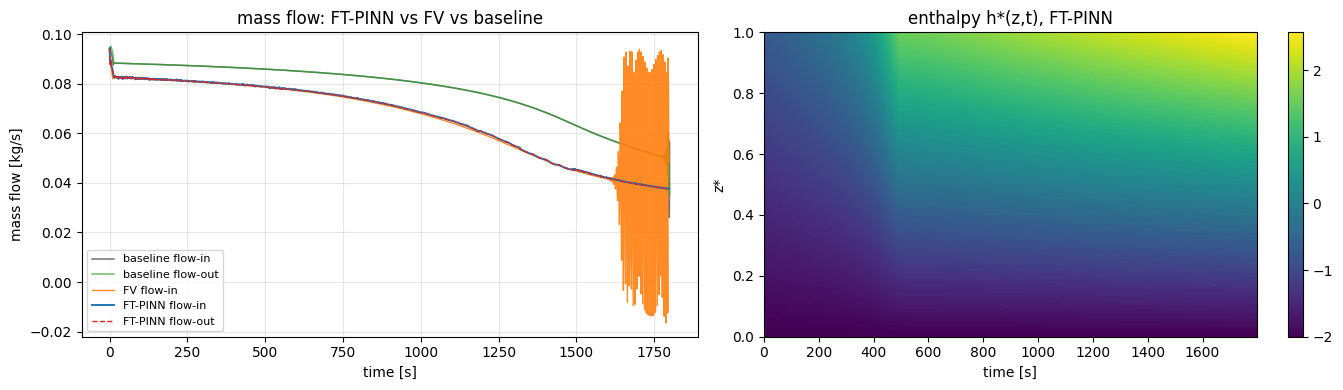

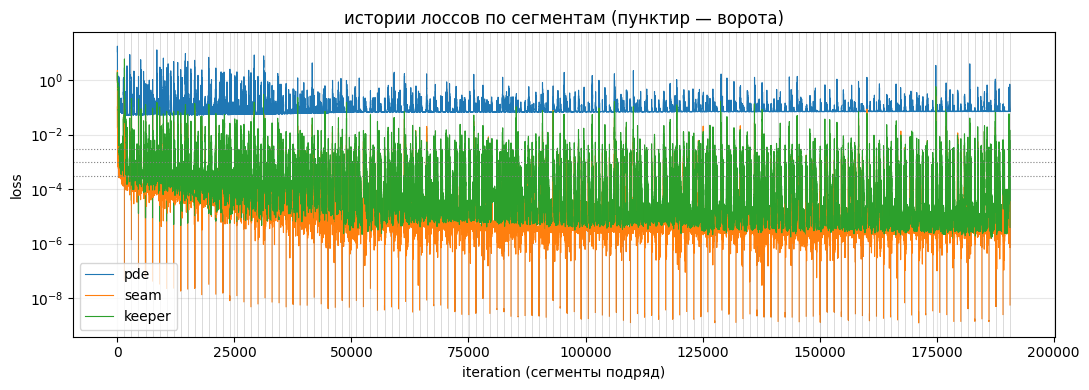

 seg  t_lo       t_hi      pde         seam   keeper  PASS
   0   0.0  20.000000 0.055348 4.529572e-08 0.000332 False
   1  20.0  40.000000 0.054125 1.403789e-06 0.000041 False
   2  40.0  60.000000 0.053270 8.277932e-08 0.000013 False
   3  60.0  80.000000 0.052886 6.397425e-08 0.000009 False
   4  80.0 100.000000 0.053373 4.206363e-08 0.000009 False
   5 100.0 120.000000 0.053482 3.287808e-08 0.000007 False
   6 120.0 140.000000 0.053158 2.256070e-08 0.000007 False
   7 140.0 160.000000 0.053320 2.327796e-08 0.000005 False
   8 160.0 180.000000 0.053126 1.844444e-08 0.000005 False
   9 180.0 200.000000 0.053338 2.159436e-08 0.000006 False
  10 200.0 220.000000 0.053820 2.296742e-08 0.000011 False
  11 220.0 240.000000 0.053453 1.341684e-08 0.000006 False
  12 240.0 260.000000 0.054753 3.244333e-08 0.000013 False
  13 260.0 280.000000 0.054188 1.404146e-08 0.000007 False
  14 280.0 300.000000 0.053909 1.547648e-08 0.000006 False
  15 300.0 320.000000 0.054237 1.171903e-08 0.000006 Fal

In [19]:
t_sec = np.concatenate(state["t_sec"])
Gin_kgs = np.concatenate(state["Gin_kgs"])
Gout_kgs = np.concatenate(state["Gout_kgs"])
hmap = np.concatenate(state["hmap"], axis=1)
hmap_t = np.concatenate(state["hmap_t_sec"])

ref = np.load("fv_reference_curve.npz")

# --- ворота: огибающая против FV на покрытом окне ---
m_cov = (ref["t_sec"] >= t_sec[0]) & (ref["t_sec"] <= t_sec[-1])
Gin_on_ref = np.interp(ref["t_sec"][m_cov], t_sec, Gin_kgs)
env_err = float(np.mean(np.abs(Gin_on_ref - ref["Gin_kgs"][m_cov])) / np.mean(np.abs(ref["Gin_kgs"][m_cov])))
cov_frac = t_sec[-1] / ref["t_sec"][-1]
print(f"покрытие марша: t <= {t_sec[-1]:.1f} s ({100*cov_frac:.1f}% горизонта FV)")
print(f"ошибка огибающей G_in vs FV: {100*env_err:.2f}%  (ворота {100*GATE_ENV:.0f}%: "
      f"{'PASS' if env_err <= GATE_ENV else 'FAIL'})")

# --- канонический график (стиль FV-ноутбука): расход + heatmap ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(forcing.time, forcing.flow_in, color="k", lw=1.1, alpha=0.55, label="baseline flow-in")
ax[0].plot(forcing.time, forcing.flow_out, color="tab:green", lw=1.1, alpha=0.7, label="baseline flow-out")
ax[0].plot(ref["t_sec"], ref["Gin_kgs"], color="tab:orange", lw=1.0, alpha=0.9, label="FV flow-in")
ax[0].plot(t_sec, Gin_kgs, color="tab:blue", lw=1.4, label="FT-PINN flow-in")
ax[0].plot(t_sec, Gout_kgs, "--", color="tab:red", lw=1.0, label="FT-PINN flow-out")
ax[0].set_xlabel("time [s]"); ax[0].set_ylabel("mass flow [kg/s]")
ax[0].set_title("mass flow: FT-PINN vs FV vs baseline"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
im = ax[1].imshow(hmap, aspect="auto", origin="lower",
                  extent=[hmap_t[0], hmap_t[-1], 0, 1])
ax[1].set_xlabel("time [s]"); ax[1].set_ylabel("z*"); ax[1].set_title("enthalpy h*(z,t), FT-PINN")
fig.colorbar(im, ax=ax[1]); plt.tight_layout(); plt.show()

# --- истории лоссов по сегментам ---
fig, ax = plt.subplots(figsize=(11, 4))
off = 0
for i, hist in enumerate(state["hist"]):
    it = np.arange(off, off + len(hist))
    for key, color in [("pde", "tab:blue"), ("seam", "tab:orange"), ("keeper", "tab:green")]:
        ax.semilogy(it, [h[key] for h in hist], color=color, lw=0.8,
                    label=key if i == 0 else None)
    off += len(hist)
    ax.axvline(off, color="gray", lw=0.4, alpha=0.5)
for y, name in [(GATE_PDE, "pde"), (GATE_SEAM, "seam"), (GATE_KEEPER, "keeper")]:
    ax.axhline(y, ls=":", lw=0.8, color="gray")
ax.set_xlabel("iteration (сегменты подряд)"); ax.set_ylabel("loss")
ax.set_title("истории лоссов по сегментам (пунктир — ворота)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# --- посегментный отчёт по воротам ---
gdf = pd.DataFrame(state["gates"])
gdf["PASS"] = gdf["gate_pde"] & gdf["gate_seam"] & gdf["gate_keeper"]
print(gdf[["seg", "t_lo", "t_hi", "pde", "seam", "keeper", "PASS"]].to_string(index=False))

# --- ворота DWO (только при покрытии хвоста) ---
if t_sec[-1] > 1650.0:
    m_tail = t_sec > 1650.0
    s = Gin_kgs[m_tail] - Gin_kgs[m_tail].mean()
    dt_s = float(np.mean(np.diff(t_sec[m_tail])))
    freq = np.fft.rfftfreq(len(s), d=dt_s)
    spec = np.abs(np.fft.rfft(s))
    period = 1.0 / freq[int(np.argmax(spec[1:])) + 1]
    w = 20
    p2p = np.array([np.ptp(Gin_kgs[max(0, j - w):j + w]) for j in range(len(Gin_kgs))])
    base_p2p = p2p[(t_sec > 200) & (t_sec < 1200)].mean()
    onset = float(t_sec[np.argmax(p2p > 10 * base_p2p)])
    ok_p = abs(period - 5.93) / 5.93 <= 0.15
    ok_o = abs(onset - 1626.0) / 1626.0 <= 0.15
    print(f"DWO: период {period:.2f} s (эталон 5.93 ± 15%: {'PASS' if ok_p else 'FAIL'}), "
          f"onset {onset:.0f} s (эталон 1626 ± 15%: {'PASS' if ok_o else 'FAIL'})")
else:
    print("DWO-ворота: покрытие < 1650 s — оцениваются только на пресете full")


### Заметки / рычаги

- **Рычаги при провале посегментных ворот** (Appendix B статьи): σ_τ (частотная полоса временных RFF; у них ошибка растёт на 3 порядка при σ_ξ: 1→8, к σ_τ чувствительность мягче с оптимумом 2) и бюджет L-BFGS (`lbfgs_steps`, `lbfgs_rounds`). Третий рычаг — ΔΓ: короче сегмент → проще каждое окно, но больше накопление ошибки шва (их Fig. B1).
- **Первые сегменты** стартуют с холодного равномерного IC (штатный `ic_loss`): резкий стартовый переходный процесс может держать pde-ворота красными на первом сегменте — смотреть распад ошибки по сегментам, прежде чем крутить веса.
- **Ресумабельность:** `RESUME=True` продолжает марш с последнего сегмента из `v7_ftpinn_ckpt.pt`; пресеты используют одно расписание, так что после `smoke` можно продолжить `envelope`/`full` без пересчёта первых сегментов. Для чистого перезапуска — удалить чекпоинт.
- **Протокол:** сначала `smoke` (2 сегмента, ~5–10 мин) — машинерия и первые числа ворот; затем `envelope` (35 сегментов, огибающая до 1487 s, ворота ≤3% vs FV); затем `full` (~127 сегментов) — главный вопрос: появляются ли DWO (период 5.93 s ± 15%, onset 1626 s ± 15%).
